# Projet Machine Learning : Prédiction de Survie sur le Titanic


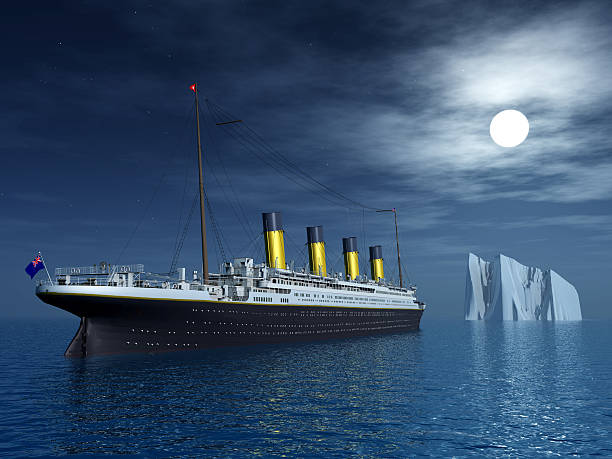

In [352]:
from IPython.display import Image, display

# Suppose que l'image est uploadée dans Colab (ex: 'mon_image.png')
display(Image(filename='images/titanic.jpg'))


## Description du projet
Ce projet a pour objectif de **prévoir la survie des passagers du Titanic** en utilisant des techniques de **Machine Learning**.  
Nous allons travailler sur la base de données prédéfinie du Titanic, qui contient des informations sur les passagers telles que l'âge, le sexe, la classe du billet, le nombre de frères/sœurs à bord, etc.  

Le projet est structuré en plusieurs étapes clés selon le processus ECD : Exploration et Connaissance des Données.  

1. **Chargement et exploration des données** : Compréhension des variables et identification des valeurs manquantes.  
2. **Prétraitement des données** : Nettoyage, traitement des valeurs manquantes, encodage des variables catégorielles.  
3. **Analyse exploratoire des données (EDA)** : Visualisations pour mieux comprendre les relations entre variables et la survie.  
4. **Construction et entraînement des modèles ML** : Application de plusieurs algorithmes de classification (ex. K-NN, SVM, Random Forest, ...).  
5. **Évaluation des modèles** : Utilisation de métriques telles que l'accuracy, la précision, le rappel (Recall) et le F1-score pour comparer les performances.  
6. **Prédictions** : Prédiction de la survie pour de nouveaux passagers.  
7. **Visualisation et interface graphique** : Création d'une interface simple pour tester le modèle et visualiser les résultats.  

Ce notebook servira à **documenter chaque étape** de manière claire avec des explications, des visualisations et du code commenté.


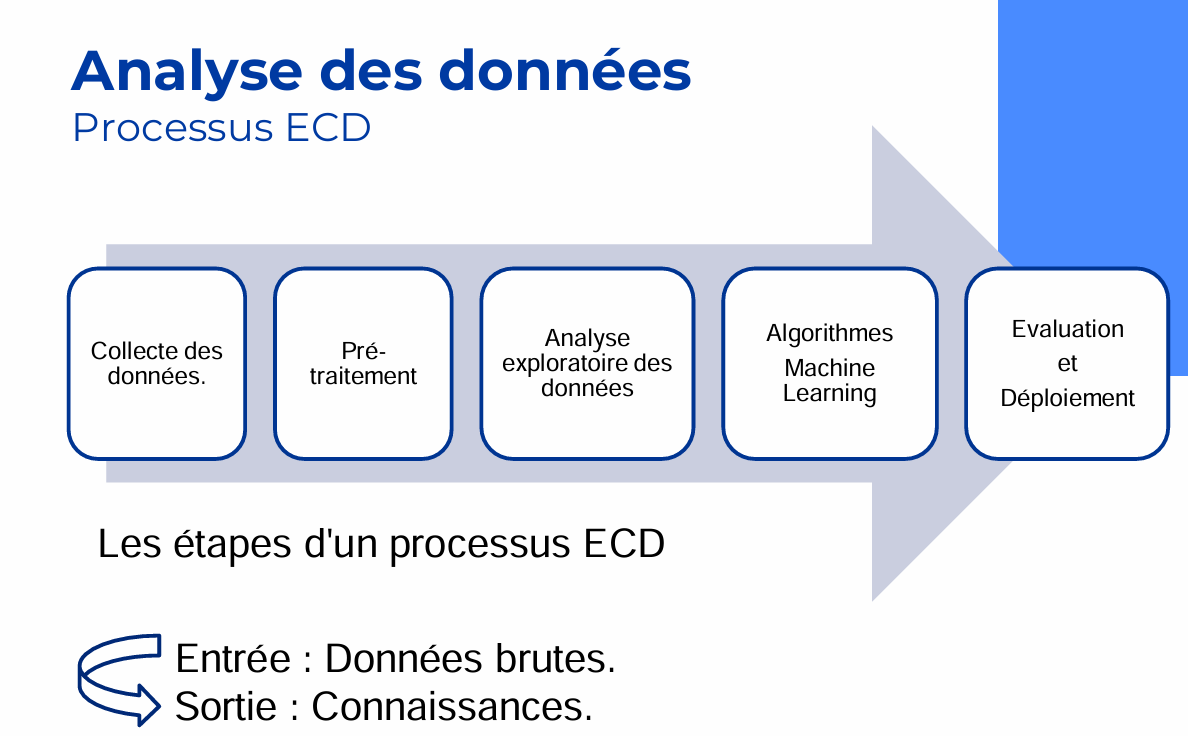

In [353]:
from IPython.display import Image, display

# Suppose que l'image est uploadée dans Colab (ex: 'mon_image.png')
display(Image(filename='images/ECD.png'))

# 1. Chargement et Exploration des Données

## Importation des bibliothèques nécessaires
Dans cette étape, nous importons toutes les bibliothèques essentielles pour le Machine Learning et l'analyse des données.  
Cela inclut `pandas`, `numpy`, `matplotlib`, `seaborn`, `sklearn` et autres selon les besoins.


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Modèles de classification
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


# Sauvegarde du modèle
import joblib
import os
import pickle
import warnings
warnings.filterwarnings("ignore")




## Chargement de la base Titanic
Nous utilisons la bibliothèque **Seaborn** pour charger la dataset Titanic, qui contient les informations sur les passagers, telles que :
- Âge
- Sexe
- Classe du billet
- Nombre de frères/sœurs à bord
- Survie ,...

Ensuite, nous explorons rapidement les premières lignes et les informations générales de la dataset.

In [355]:
df = sns.load_dataset("titanic")
df.head(10)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True
5,0,3,male,NaN,0,0,8.4583,Q,Third,man,True,NaN,Queenstown,no,True
6,0,1,male,54.0,0,0,51.8625,S,First,man,True,E,Southampton,no,True
7,0,3,male,2.0,3,1,21.0750,S,Third,child,False,NaN,Southampton,no,False
8,1,3,female,27.0,0,2,11.1333,S,Third,woman,False,NaN,Southampton,yes,False
9,1,2,female,14.0,1,0,30.0708,C,Second,child,False,NaN,Cherbourg,yes,False


## Description des colonnes du jeu de données Titanic

### survived
Indique si le passager a survécu au naufrage.  
- `0` : N’a pas survécu  
- `1` : A survécu  

### pclass
Classe du billet du passager, représentant le niveau socio-économique.  
- `1` : Première classe  
- `2` : Deuxième classe  
- `3` : Troisième classe  

### sex
Sexe du passager.  
- `male` : Homme  
- `female` : Femme  

### age
Âge du passager en années.  
- Peut contenir des valeurs manquantes (`NaN`)

### sibsp
Nombre de frères/sœurs et conjoints du passager à bord du Titanic.

### parch
Nombre de parents et enfants du passager à bord du Titanic.

### fare
Prix du billet payé par le passager.

### embarked
Port d’embarquement du passager.  
- `C` : Cherbourg  
- `Q` : Queenstown  
- `S` : Southampton  

### class
Classe du passager sous forme textuelle.  
- `First` : Première classe  
- `Second` : Deuxième classe  
- `Third` : Troisième classe  

### who
Catégorie simplifiée du passager selon l’âge et le sexe.  
- `man` : Homme adulte  
- `woman` : Femme adulte  
- `child` : Enfant  

### adult_male
Indique si le passager est un homme adulte.  
- `True` : Homme adulte  
- `False` : Sinon  

### deck
Pont du navire où se trouvait la cabine du passager.  
- Peut contenir des valeurs manquantes (`NaN`)

### embark_town
Nom complet de la ville d’embarquement du passager.  
- Southampton  
- Cherbourg  
- Queenstown  

### alive
Indique si le passager est en vie après le naufrage.  
- `yes` : Vivant  
- `no` : Décédé  

### alone
Indique si le passager voyageait seul.  
- `True` : Voyageait seul  
- `False` : Voyageait avec de la famille


# 2. Prétraitement des Données

Le prétraitement a pour objectif de **nettoyer et structurer les données** afin de les rendre exploitables pour les modèles de Machine Learning.  
Les principales étapes sont les suivantes :

## 2.1 Informations sur la dataset
- Permet de connaître :
  - Les types des colonnes
  - La présence de valeurs manquantes (NaN)
  - Le nombre d'observations


In [356]:
# Informations sur le DataFrame : taille, types de données, etc.
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [357]:
# Statistique descriptives sur les données du DataFrame sur les colonnes numériques
df.describe()


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [358]:
# Vérification des types de données de chaque colonne
df.dtypes

survived          int64
pclass            int64
sex              object
age             float64
sibsp             int64
parch             int64
fare            float64
embarked         object
class          category
who              object
adult_male         bool
deck           category
embark_town      object
alive            object
alone              bool
dtype: object

### Suppression des colonnes non pertinentes

Certaines colonnes de la base de données Titanic ne sont **pas utiles pour la prédiction de la survie** ou contiennent des informations redondantes.  
Nous les supprimons afin de **simplifier le modèle**, réduire le bruit et éviter des biais inutiles.

Les colonnes supprimées sont :

- **deck** : contient un grand nombre de valeurs manquantes (NaN), ce qui la rend peu exploitable.
- **embark_town** : information redondante avec la colonne `embarked`.
- **alive** : variable cible déjà représentée par `survived` (risque de fuite de données).
- **class** : redondante avec la variable numérique `pclass`.
- **who** : information dérivée du sexe et de l'âge, déjà présentes dans la dataset.
- **adult_male** : variable booléenne directement calculée à partir de `sex` et `age`.

Cette étape permet d'améliorer la **qualité des données**, de réduire la **complexité du modèle** et d'assurer un apprentissage plus efficace.


In [359]:
df.drop(columns=[
    "deck",
    "embark_town",
    "alive",
    "class",
    "who",
    "adult_male"
], inplace=True)

# Vérification des valeurs manquantes
df.tail(10)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone
881,0,3,male,33.0,0,0,7.8958,S,True
882,0,3,female,22.0,0,0,10.5167,S,True
883,0,2,male,28.0,0,0,10.5000,S,True
884,0,3,male,25.0,0,0,7.0500,S,True
885,0,3,female,39.0,0,5,29.1250,Q,False
886,0,2,male,27.0,0,0,13.0000,S,True
887,1,1,female,19.0,0,0,30.0000,S,True
888,0,3,female,NaN,1,2,23.4500,S,False
889,1,1,male,26.0,0,0,30.0000,C,True
890,0,3,male,32.0,0,0,7.7500,Q,True


## 2.2 Identification des valeurs manquantes
- Utilisation de `isnull().sum()` pour compter les NaN par colonne
- Vérification que leur proportion est faible pour éviter de supprimer trop de lignes


In [360]:
df.isnull().sum()
# Nombre de valeurs manquantes par colonne car isnull() renvoie un DataFrame de booléens 1 = True pour les valeurs manquantes et la fonction sum() fait la somme des valeurs True (1) pour chaque colonne
# sum() est une attribut de l'objet DataFrame qui calcule la somme des valeurs le long d'un axe spécifié (par défaut, l'axe 0, c'est-à-dire les colonnes).

survived      0
pclass        0
sex           0
age         177
sibsp         0
parch         0
fare          0
embarked      2
alone         0
dtype: int64

## Séparation des colonnes selon le type de variables

### Variables qualitatives nominales
Variables catégorielles **sans ordre naturel**.

- **sex** : `male`, `female`
- **embarked** : `S`, `C`, `Q`
- **alone** : `True`, `False`


### Variables qualitatives ordinales
Variables catégorielles **avec un ordre naturel**.

- **pclass** :  
  - `1` : Première classe  
  - `2` : Deuxième classe  
  - `3` : Troisième classe  

### Variables quantitatives discrètes
Variables numériques issues d’un **comptage** (valeurs entières).

- **sibsp** : nombre de frères/sœurs et conjoints
- **parch** : nombre de parents et enfants


### Variables quantitatives continues
Variables numériques issues d’une **mesure**.

- **age** : âge du passager (peut contenir des NaN)
- **fare** : prix du billet


### Variable cible (label)
Variable à prédire dans un problème de classification.

- **survived** :  
  - `0` : n’a pas survécu  
  - `1` : a survécu


## 2.3 Imputation des valeurs manquantes

Avant toute imputation, nous évaluons la **proportion de valeurs manquantes** afin de choisir une stratégie adaptée.

#### Décision basée sur la proportion de NaN
- **Proportion < 5%** → suppression possible des lignes (`dropna`)
- **Proportion ≥ 5%** → imputation recommandée

#### Règles d’imputation appliquées
Une seule méthode est utilisée par type de variable :

- **Variables qualitatives (nominales / ordinales)** → `mode()`
- **Variables quantitatives discrètes** → `median()`
- **Variables quantitatives continues** → `mean()`

N.B:
Variables quantitatives discrètes: sont des nombres entiers issus d’un comptage,... . Donc le choix de median() vient de fait qu'elle n’est pas influencée par les valeurs extrêmes.

Cette stratégie permet de préserver la structure statistique des données tout en limitant les biais.



In [361]:
# Nombre total de lignes
total = len(df)

# Nombre de lignes contenant au moins un NaN
nb_nan_rows = df.isnull().any(axis=1).sum()

# Proportion
proportion = (nb_nan_rows / total) * 100

print(f"Total lignes : {total}")
print(f"Lignes avec NaN : {nb_nan_rows}")
print(f"Proportion : {proportion:.2f}%")

# Décision
if proportion < 5:
    print("→ Proportion faible : suppression des lignes avec NaN")
    df = df.dropna()
else:
    print("→ Proportion élevée : imputation appliquée")

    def clean_missing_values(df):
        df_clean = df.copy()

        strategies = {
            # Qualitatives nominales / ordinales → mode
            "sex": "mode",
            "embarked": "mode",
            "alone": "mode",
            "pclass": "mode",

            # Quantitatives discrètes → median
            "sibsp": "median",
            "parch": "median",

            # Quantitatives continues → mean
            "age": "mean",
            "fare": "mean"
        }

        for col, strategy in strategies.items():
            if col in df_clean.columns and df_clean[col].isnull().sum() > 0:
                if strategy == "mode":
                    fill_value = df_clean[col].mode()[0]
                elif strategy == "mean":
                    fill_value = df_clean[col].mean()
                elif strategy == "median":
                    fill_value = df_clean[col].median()

                df_clean[col].fillna(fill_value, inplace=True)
                print(f"✅ {col} : imputé avec {strategy} ({fill_value})")

        return df_clean

    df = clean_missing_values(df)

# Vérification finale
print("\nValeurs manquantes restantes :")
print(df.isnull().sum())


Total lignes : 891
Lignes avec NaN : 179
Proportion : 20.09%
→ Proportion élevée : imputation appliquée
✅ embarked : imputé avec mode (S)
✅ age : imputé avec mean (29.69911764705882)

Valeurs manquantes restantes :
survived    0
pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
alone       0
dtype: int64


##### N.B:

Pour l’imputation des valeurs manquantes (`NaN`), deux méthodes principales peuvent être utilisées en pandas : **`fillna()`** et **`replace()`**.  
Le choix de la méthode dépend du contexte et du niveau de contrôle souhaité.


##### 1- Méthode `fillna()`

La méthode `fillna()` est spécifiquement conçue pour **remplacer les valeurs manquantes** dans une colonne ou dans l’ensemble du DataFrame.

**Caractéristiques :**
- Remplace uniquement les valeurs `NaN`
- Simple et lisible
- Très adaptée à l’imputation statistique (moyenne, médiane, mode)
- Utilisée colonne par colonne ou sur plusieurs colonnes

**Cas d’utilisation :**
- Imputation classique dans les projets de Machine Learning
- Remplacement basé sur des statistiques descriptives
- Nettoyage standard des données


##### 2- Méthode `replace()`

La méthode `replace()` permet de **remplacer une ou plusieurs valeurs par d’autres**, y compris les `NaN`.

**Caractéristiques :**
- Plus générale que `fillna()`
- Peut remplacer plusieurs valeurs en une seule opération
- Utile lorsque l’on souhaite appliquer des règles de remplacement plus complexes
- Peut être appliquée sur des sous-ensembles de colonnes

**Cas d’utilisation :**
- Remplacements multiples ou conditionnels
- Transformation avancée des données
- Nettoyage de valeurs spécifiques en plus des `NaN`


### Choix de la méthode dans ce projet

Dans ce projet, la méthode **`fillna()` est privilégiée** pour l’imputation, car elle est :
- Plus explicite
- Plus simple à interpréter
- Parfaitement adaptée aux règles d’imputation définies selon le type des variables

La méthode `replace()` reste une alternative valable lorsque des règles de remplacement plus complexes sont nécessaires.


## 2.4 Détection et traitement des outliers

Les **outliers (valeurs aberrantes)** sont des valeurs extrêmes pouvant fausser l’analyse et les modèles. Leur détection dépend du **type de variable** et de la **distribution des données**.

### Méthodes principales de détection

- **Méthode IQR (Interquartile Range)**  
  - Basée sur les quartiles (Q1, Q3)
  - Intervalle normal :
    ```
    [Q1 − 1.5×IQR ; Q3 + 1.5×IQR]
    ```
  - ✔ Recommandée pour les données non normales  
  - ✔ Robuste aux valeurs extrêmes  
  - **À utiliser dans le code :** `quantile()`

- **Méthode Z-score**  
  - Basée sur la moyenne et l’écart-type
  - Outlier si :
    ```
    |Z| > 3
    ```
  - ✔ Adaptée aux données suivant une loi normale  
  - ❌ Sensible aux valeurs extrêmes  
  - **À utiliser dans le code :** `scipy.stats.zscore()`

- **Méthode des percentiles (quantiles)**  
  - Définition de seuils (ex. 1% et 99%)
  - Valeurs hors bornes considérées comme outliers
  - ✔ Simple et flexible  
  - ✔ Utile pour données très asymétriques  
  - **À utiliser dans le code :** `quantile()`

- **Méthode visuelle (Boxplot / Histogramme)**  
  - Inspection graphique des valeurs extrêmes
  - ✔ Complémentaire aux méthodes statistiques  
  - **À utiliser dans le code :** `boxplot()`, `hist()`


In [362]:
# Sélection des colonnes numériques continues
num_cols = ['age', 'fare', 'sibsp', 'parch']

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    # Calcul des bornes (le `1.5` est un facteur communément utilisé pour détecter les outliers avec plus de robustesse "détecter les valeurs anormalement éloignéeses" que les simples minimum et maximum)
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Affichage du nombre d'outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"{col} : {len(outliers)} outliers")

    # Suppression des outliers (optionnel)
    # df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]


age : 66 outliers
fare : 116 outliers
sibsp : 46 outliers
parch : 213 outliers


#####  Pourquoi ne pas supprimer les outliers pour le dataset Titanic ?

1. **Représentativité des données**
   - Certains outliers correspondent à **des cas réels et significatifs** :
     - `age` : très jeunes enfants ou passagers très âgés  
     - `fare` : tarifs très élevés pour des passagers de première classe ou VIP  
     - `sibsp` et `parch` : familles nombreuses à bord
   - Supprimer ces valeurs reviendrait à **perdre de l’information utile** pour la prédiction de la survie.

2. **Impact sur le modèle**
   - Certains algorithmes ML (ex. Random Forest, Arbre de décision) **ne sont pas sensibles aux outliers**, donc la suppression n’est pas nécessaire.
   - Les outliers peuvent même **apporter des signaux importants** (ex. un passager riche ou isolé avait plus/moins de chances de survie).

3. **Robustesse de la détection**
   - La méthode IQR est utilisée uniquement pour **identifier les outliers**, pas pour les supprimer systématiquement.
   - Elle permet d’**analyser la distribution des données** et de préparer éventuellement des transformations (ex. logarithme pour `fare`) si nécessaire.



### Outliers pour les variables catégorielles (qualitatives)

Contrairement aux variables numériques, les **variables qualitatives nominales ou ordinales** n’ont pas de notion de grandeur.  
Ainsi, un "outlier" n’est pas une valeur extrême, mais plutôt une **modalité rare ou inhabituelle** qui apparaît très peu dans le jeu de données.

#### Détection
- **Fréquence des modalités** : compter combien de fois chaque catégorie apparaît.
  - Exemple : `df['sex'].value_counts()`
- **Seuil de rareté** : on peut considérer comme rare une modalité représentant moins de 1% ou 5% des données.
- **Visualisation** : diagramme en barres (`countplot`) pour repérer les catégories peu représentées.

#### Traitement
- Fusionner les catégories rares dans une catégorie `Autre` ou `Rare`
- Vérifier si ces valeurs rares sont correctes ou s’il s’agit d’erreurs de saisie
- Laisser telles quelles si elles sont valides et significatives

**Remarque :**
> Pour les colonnes catégorielles, les outliers ne sont pas des valeurs extrêmes numériques, mais des **modalités rares ou erronées**. Leur traitement dépend du contexte et de l’importance de ces catégories pour l’analyse.


## 2.5 Encodage des variables catégorielles

Les **variables catégorielles** doivent être converties en **valeurs numériques** pour être utilisées par les modèles de Machine Learning.  
Il existe plusieurs méthodes d'encodage selon le type de variable et le modèle.



### 1️. `get_dummies` (One-Hot Encoding)
- Transforme chaque modalité en **une colonne binaire** (0 ou 1)
- Exemple : `sex` → `sex_male`, `sex_female`
- Avantages :
  - Compatible avec la plupart des modèles ML
  - Préserve toute l’information
- Inconvénient :
  - Peut augmenter fortement le nombre de colonnes si la variable a beaucoup de modalités


### 2️. `OneHotEncoder` (de scikit-learn)
- Transforme les modalités en **vecteurs binaires**
- Semblable à `get_dummies`, mais **intégré dans les pipelines scikit-learn**
- Avantages :
  - Compatible avec `ColumnTransformer` et pipelines
  - Peut gérer les valeurs inconnues lors de la prédiction
- Inconvénient :
  - Syntaxe légèrement plus complexe que `get_dummies`
- ohe = OneHotEncoder(); ohe.fit_transform(df[['col']])
- return np array qui besoin transformation vers dataframe
```
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(drop='first', sparse=False)  # drop='first' pour éviter le dummy trap
# Renvoie un tableau complet Numpy au lieu d’une matrice creuse
encoded_array = ohe.fit_transform(df[['sex', 'embarked']])
encoded_df = pd.DataFrame(encoded_array, columns=ohe.get_feature_names_out(['sex', 'embarked']))
# encoded_df est un DataFrame Pandas avec les colonnes binaires
```

### 3. `LabelEncoder`
- Attribue un **entier unique à chaque modalité**
- Exemple : `sex` → male=1, female=0
- Avantages :
  - Simple et rapide
  - Pas d’augmentation du nombre de colonnes
- Inconvénient :
  - Introduit un **ordre artificiel**, peut biaiser certains modèles (ex. régression linéaire)


### 4. `map()`
- Permet de **transformer manuellement les modalités**
- Avantages :
  - Contrôle total sur les valeurs assignées
  - Idéal pour les variables binaires ou ordinales
- Inconvénient :
  - Moins pratique pour de nombreuses modalités
  - Opération manuelle


### Comparaison rapide

| Méthode           | Type de variable         | Avantage                        | Inconvénient                         |
|------------------|------------------------|---------------------------------|-------------------------------------|
| `get_dummies`     | Nominale               | Compatible avec tous les modèles| Augmente le nombre de colonnes      |
| `OneHotEncoder`   | Nominale               | Intégré aux pipelines           | Syntaxe plus complexe                |
| `LabelEncoder`    | Nominale / Ordinale    | Simple et rapide                | Introduit un ordre artificiel       |
| `map()`           | Nominale / Ordinale    | Contrôle total                  | Moins pratique pour nombreuses modalités |



In [363]:
df = pd.get_dummies(df, columns=['sex', 'embarked'], drop_first=False)
df.head()


,survived,pclass,age,sibsp,parch,fare,alone,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,0,3,22.0,1,0,7.2500,False,False,True,False,False,True
1,1,1,38.0,1,0,71.2833,False,True,False,True,False,False
2,1,3,26.0,0,0,7.9250,True,True,False,False,False,True
3,1,1,35.0,1,0,53.1000,False,True,False,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True,False,False,True


## 2.6 Normalisation / Standardisation

Dans cette étape, nous préparons les **variables numériques** pour les modèles de Machine Learning.  
L’objectif est de **rendre les variables comparables entre elles** et d’éviter que certaines variables dominent les modèles à cause de leurs grandes valeurs.


### Méthode utilisée : StandardScaler (Z-Score)

- Transforme les données pour avoir :
  - **Moyenne = 0**
  - **Écart-type = 1**
- Formule :

![image.png](attachment:image.png)

où :
- \(x\) = valeur originale  
- \(mu\) = moyenne de la colonne  
- \(sigma\) = écart-type de la colonne  

- Avantages :
  - Les modèles basés sur **distance ou gradient** (ex. K-NN, SVM, régression linéaire/logistique) fonctionnent mieux
  - Préserve la **distribution des données** (forme similaire à l’originale)



### Normalisation vs Standardisation

| Méthode            | Principe                              | Quand l’utiliser                       |
|-------------------|--------------------------------------|---------------------------------------|
| **Standardisation**| Centrer sur 0 et écart-type = 1       | Variables numériques avec différentes échelles, utile pour ML |
| **Normalisation**  | Mettre les valeurs entre 0 et 1       | Variables avec bornes fixes ou pour réseaux neuronaux |

- En résumé :
  - **Standardisation** = centrer et réduire (Z-Score)  
  - **Normalisation** = rescaler entre 0 et 1  
  ![image-2.png](attachment:image-2.png)

````
from sklearn.preprocessing import MinMaxScaler

scale_cols = ["age", "fare", "sibsp", "parch"]
scaler = MinMaxScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

df[scale_cols].head()
````

In [364]:
from sklearn.preprocessing import StandardScaler

# Colonnes numériques continues
scale_cols = ["age", "fare", "sibsp", "parch"]

# Initialisation du scaler
scaler = StandardScaler()

# Application de la standardisation
df[scale_cols] = scaler.fit_transform(df[scale_cols])

df[scale_cols].head()


,age,fare,sibsp,parch
0,-0.592481,-0.502445,0.432793,-0.473674
1,0.638789,0.786845,0.432793,-0.473674
2,-0.284663,-0.488854,-0.474545,-0.473674
3,0.407926,0.420730,0.432793,-0.473674
4,0.407926,-0.486337,-0.474545,-0.473674


### To Add :

#### Détecter et suppression des doublons

In [365]:
# Détecter les doublons
print(df.duplicated().sum())  # Nombre de lignes dupliquées
# Supprimer les doublons
# df = df.drop_duplicates()
df.head()

111


,survived,pclass,age,sibsp,parch,fare,alone,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,0,3,-0.592481,0.432793,-0.473674,-0.502445,False,False,True,False,False,True
1,1,1,0.638789,0.432793,-0.473674,0.786845,False,True,False,True,False,False
2,1,3,-0.284663,-0.474545,-0.473674,-0.488854,True,True,False,False,False,True
3,1,1,0.407926,0.432793,-0.473674,0.420730,False,True,False,False,False,True
4,0,3,0.407926,-0.474545,-0.473674,-0.486337,True,False,True,False,False,True


In [366]:
df.dtypes

survived        int64
pclass          int64
age           float64
sibsp         float64
parch         float64
fare          float64
alone            bool
sex_female       bool
sex_male         bool
embarked_C       bool
embarked_Q       bool
embarked_S       bool
dtype: object

In [367]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   survived    891 non-null    int64  
 1   pclass      891 non-null    int64  
 2   age         891 non-null    float64
 3   sibsp       891 non-null    float64
 4   parch       891 non-null    float64
 5   fare        891 non-null    float64
 6   alone       891 non-null    bool   
 7   sex_female  891 non-null    bool   
 8   sex_male    891 non-null    bool   
 9   embarked_C  891 non-null    bool   
 10  embarked_Q  891 non-null    bool   
 11  embarked_S  891 non-null    bool   
dtypes: bool(6), float64(4), int64(2)
memory usage: 47.1 KB


## 3. Analyse exploratoire des données (EDA)

Dans cette étape, nous utilisons plusieurs types de graphiques Seaborn pour explorer la base Titanic et répondre à différentes questions :

### Méthodes utilisées

1. **Scatterplot**  
   - Nuage de points individuels → utile pour observer corrélations et classification.  
   - Exemple : relation entre âge et tarif du billet selon survie.  

2. **Lineplot**  
   - Courbe de tendance avec barres d’erreur → utile pour comparer moyennes et évolutions.  
   - Exemple : tarif moyen par classe selon survie.  

3. **Relplot (faceting)**  
   - Comparaison multi-groupe → figure complète avec sous-graphes pour comparer plusieurs sous-ensembles.  
   - Exemple : distribution de l’âge et du tarif selon sexe et survie.  

4. **Barplot**  
   - Comparaison de moyennes → utile pour visualiser taux ou moyennes catégorielles.  
   - Exemple : taux de survie par classe.  

5. **Violinplot**  
   - Distribution + densité → utile pour observer la répartition des variables numériques par catégorie.  
   - Exemple : tarif des billets selon survie et sexe.  

6. **Swarmplot**  
   - Points individuels pour chaque sous-groupe → utile pour comparer distributions discrètes.  
   - Exemple : âge par classe et survie.  




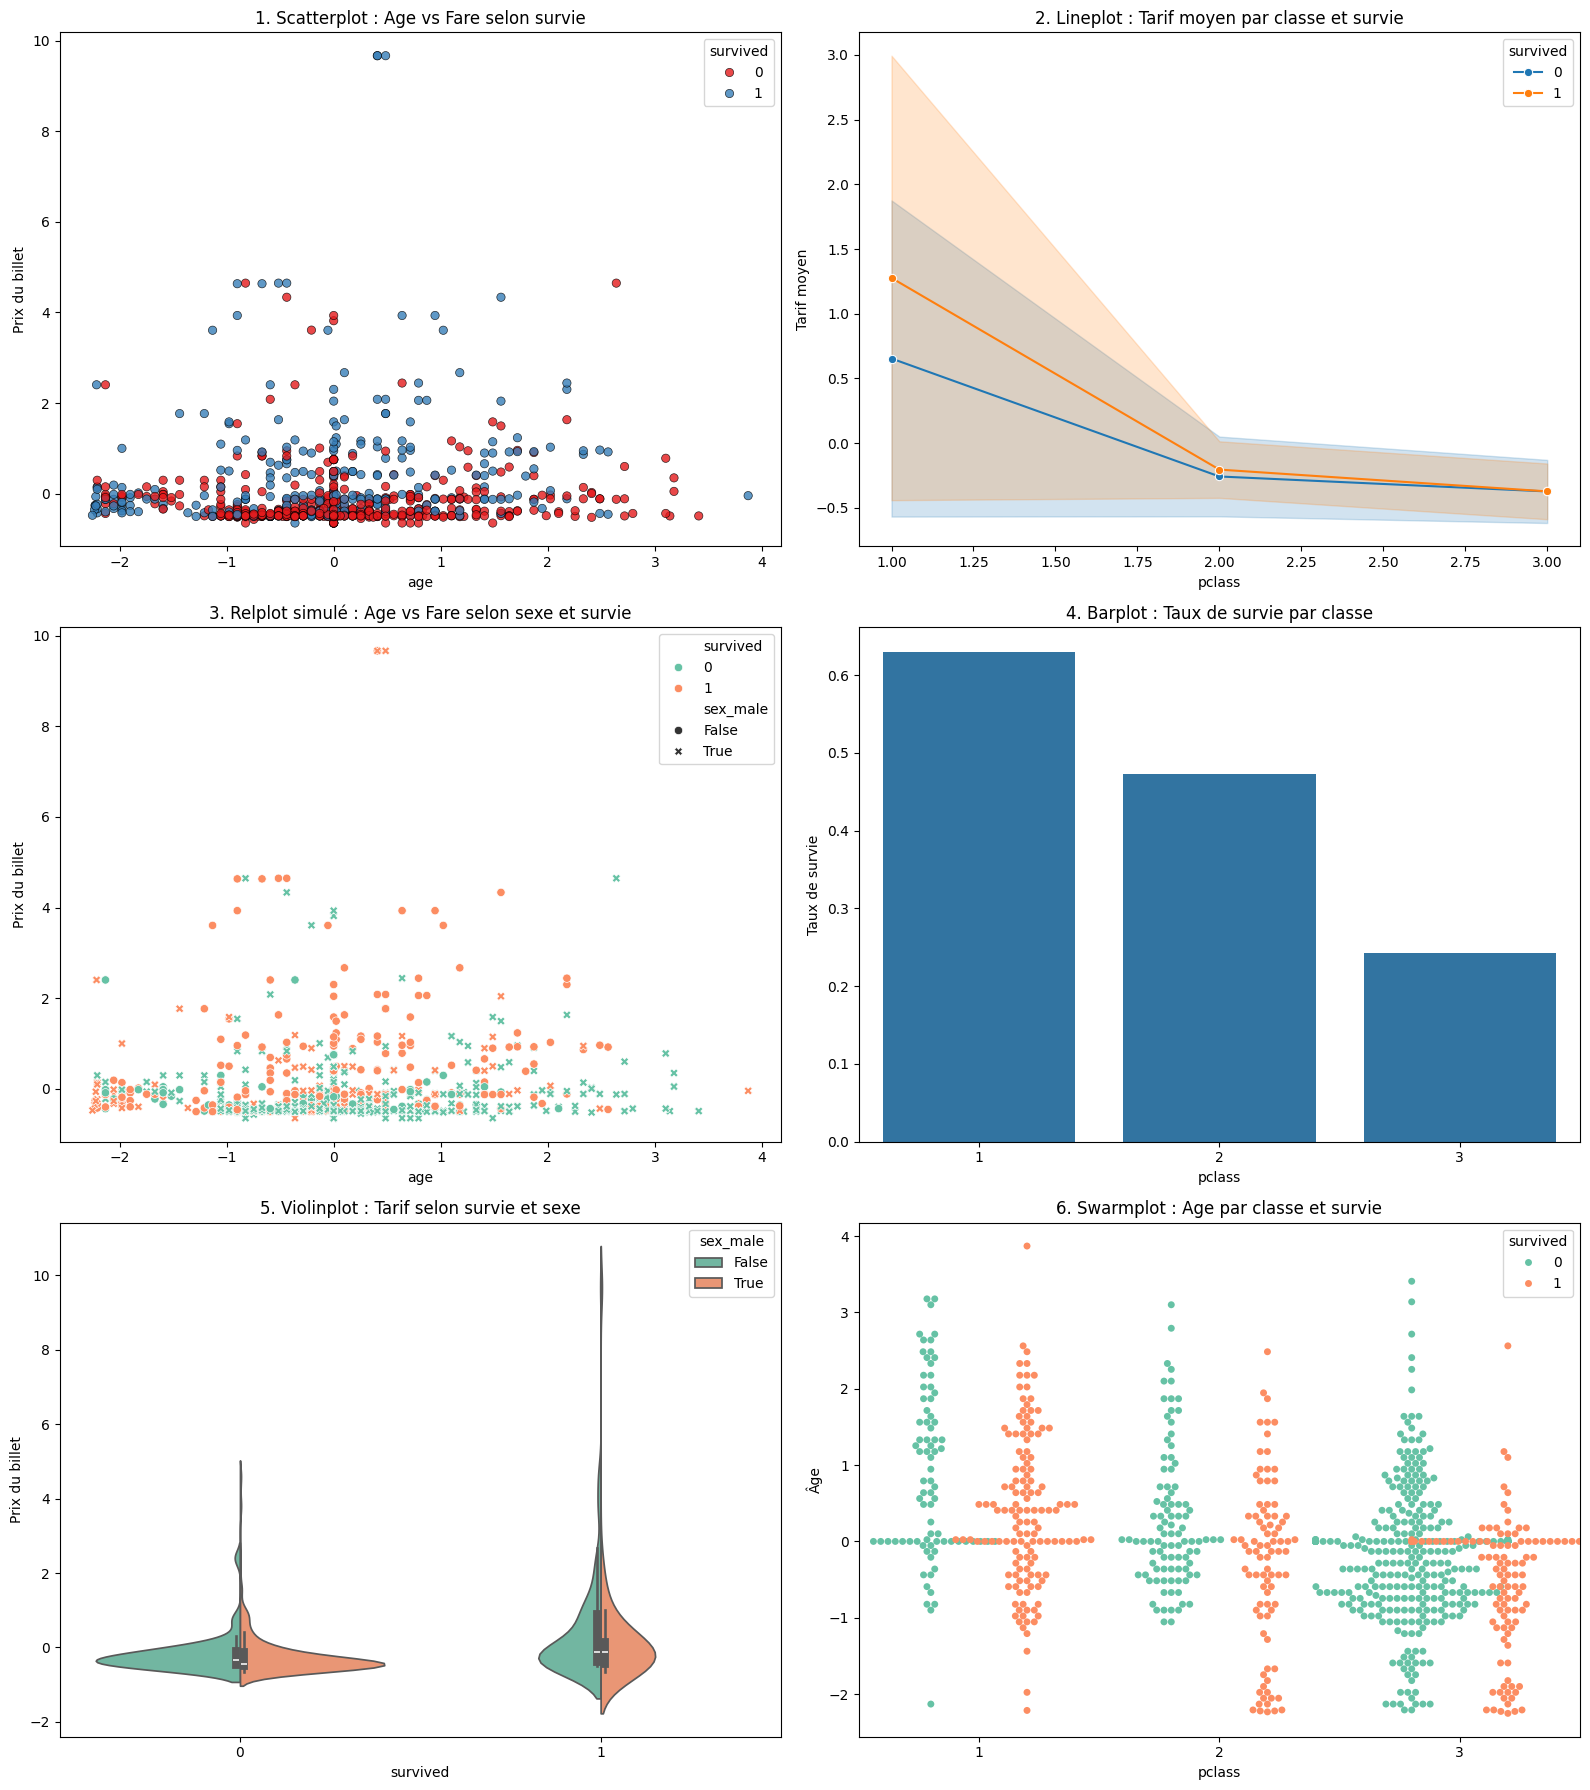

In [368]:
# Création de la figure avec 3x2 subplots
fig, axes = plt.subplots(3, 2, figsize=(16,18))

# 1️⃣ Scatterplot : Age vs Fare selon survie
sns.scatterplot(
    data=df,
    x='age',
    y='fare',
    hue='survived',
    palette='Set1',
    alpha=0.8,
    edgecolor='black',
    ax=axes[0,0]
)
axes[0,0].set_title("1. Scatterplot : Age vs Fare selon survie")
axes[0,0].set_ylabel("Prix du billet")

# 2️⃣ Lineplot : tarif moyen par classe selon survie
sns.lineplot(
    data=df,
    x='pclass',
    y='fare',
    hue='survived',
    ci='sd',
    marker='o',
    ax=axes[0,1]
)
axes[0,1].set_title("2. Lineplot : Tarif moyen par classe et survie")
axes[0,1].set_ylabel("Tarif moyen")

# 3️⃣ Relplot simulé avec scatter et style pour faceting
sns.scatterplot(
    data=df,
    x='age',
    y='fare',
    hue='survived',
    style='sex_male',  # distinction par sexe
    palette='Set2',
    ax=axes[1,0]
)
axes[1,0].set_title("3. Relplot simulé : Age vs Fare selon sexe et survie")
axes[1,0].set_ylabel("Prix du billet")

# 4️⃣ Barplot : taux de survie par classe
sns.barplot(
    data=df,
    x='pclass',
    y='survived',
    estimator=np.mean,
    errorbar=None,
    ax=axes[1,1]
)
axes[1,1].set_title("4. Barplot : Taux de survie par classe")
axes[1,1].set_ylabel("Taux de survie")

# 5️⃣ Violinplot : distribution du tarif selon survie et sexe
sns.violinplot(
    data=df,
    x='survived',
    y='fare',
    hue='sex_male',
    palette='Set2',
    orient='v',
    dodge=True,
    split=True,
    ax=axes[2,0]
)
axes[2,0].set_title("5. Violinplot : Tarif selon survie et sexe")
axes[2,0].set_ylabel("Prix du billet")

# 6️⃣ Swarmplot : distribution de l'âge selon classe et survie
sns.swarmplot(
    data=df,
    x='pclass',
    y='age',
    hue='survived',
    palette='Set2',
    dodge=True,
    ax=axes[2,1]
)
axes[2,1].set_title("6. Swarmplot : Age par classe et survie")
axes[2,1].set_ylabel("Âge")

plt.tight_layout()
plt.show()


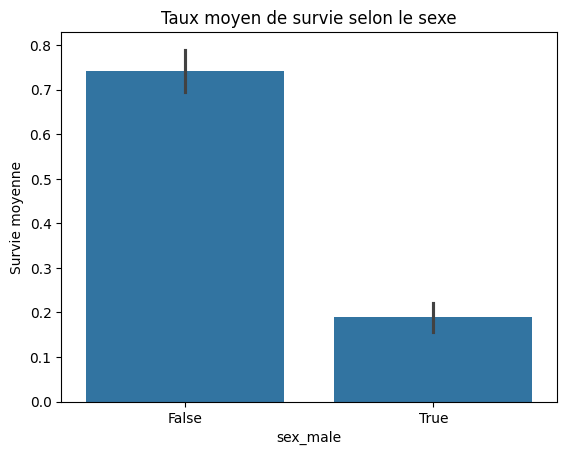

In [369]:
sns.barplot(x="sex_male", y="survived", data=df)
plt.title("Taux moyen de survie selon le sexe")
plt.ylabel("Survie moyenne")
plt.show()


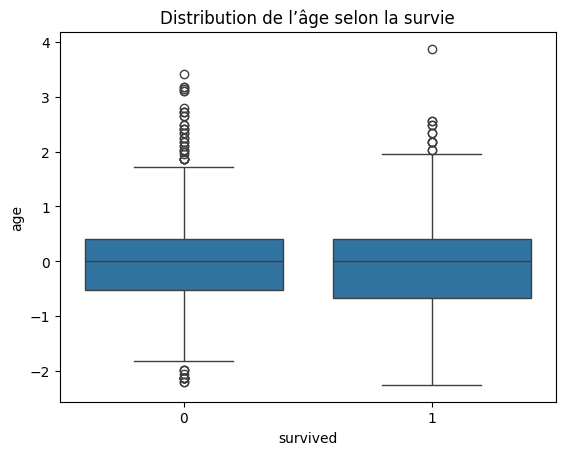

In [370]:
sns.boxplot(x="survived", y="age", data=df)
plt.title("Distribution de l’âge selon la survie")
plt.show()


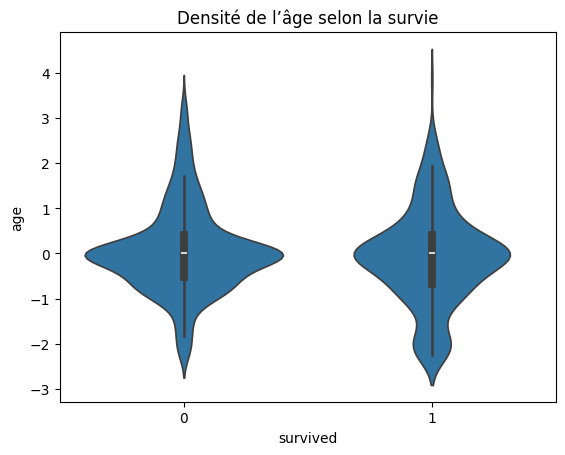

In [371]:
sns.violinplot(x="survived", y="age", data=df)
plt.title("Densité de l’âge selon la survie")
plt.show()


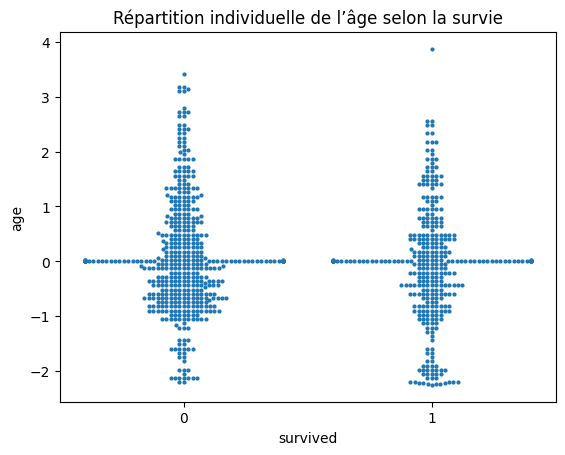

In [372]:
sns.swarmplot(x="survived", y="age", data=df, size=3)
plt.title("Répartition individuelle de l’âge selon la survie")
plt.show()


# 4. **Construction et entraînement des modèles ML**:
- Séparation des **features** (`X`) et de la **variable cible** (`y`).
  - Utilisation de `train_test_split` pour créer un **ensemble d'entraînement** et un **ensemble de test** :
  - `test_size=0.25` → 25% des données pour le test.
  - `random_state=42` → pour reproduire les mêmes résultats à chaque exécution (fixe le shuffling).

- Application de plusieurs algorithmes de classification (ex. K-NN, SVM, Random Forest, ...).  


## 4.1 Séparation des **features**

In [373]:
df.head()


,survived,pclass,age,sibsp,parch,fare,alone,sex_female,sex_male,embarked_C,embarked_Q,embarked_S
0,0,3,-0.592481,0.432793,-0.473674,-0.502445,False,False,True,False,False,True
1,1,1,0.638789,0.432793,-0.473674,0.786845,False,True,False,True,False,False
2,1,3,-0.284663,-0.474545,-0.473674,-0.488854,True,True,False,False,False,True
3,1,1,0.407926,0.432793,-0.473674,0.420730,False,True,False,False,False,True
4,0,3,0.407926,-0.474545,-0.473674,-0.486337,True,False,True,False,False,True


In [374]:
X = df.drop("survived", axis=1)
y = df["survived"]


In [375]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=42
)


## 4.2 Application de plusieurs algorithmes de classification

In [376]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC


In [377]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import numpy as np

# Liste des valeurs de k à tester
k_values = range(1, 51)  # par exemple de 1 à 50
cv_scores = []

# Boucle pour tester chaque k
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train, y_train, cv=5, scoring='accuracy')  # 5-fold CV
    cv_scores.append(scores.mean())

# Trouver le k avec le score moyen le plus élevé
best_k = k_values[np.argmax(cv_scores)]
best_score = max(cv_scores)

print(f"Meilleur k : {best_k} avec une accuracy moyenne de {best_score:.4f}")


Meilleur k : 20 avec une accuracy moyenne de 0.8158


In [378]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(n_neighbors=20),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC()
}


In [379]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():

    # Entraînement
    model.fit(X_train, y_train)

    # Prédiction
    y_pred = model.predict(X_test)

    # Évaluation
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for name, model in models.items():

    # Entraînement
    model.fit(X_train, y_train)

    # Prédiction
    y_pred = model.predict(X_test)

    # Évaluation
    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.798206,0.761905,0.719101,0.739884
1,KNN,0.816143,0.815789,0.696629,0.751515
2,Naive Bayes,0.780269,0.704082,0.775281,0.737968
3,Decision Tree,0.739910,0.678161,0.662921,0.670455
4,Random Forest,0.802691,0.764706,0.730337,0.747126
5,Gradient Boosting,0.802691,0.784810,0.696629,0.738095
6,SVM,0.825112,0.812500,0.730337,0.769231


# 5. Évaluation des modèles et sélection du meilleur

Lors de l’évaluation des modèles de classification, nous utilisons plusieurs métriques importantes pour mesurer leurs performances :

### 1. Accuracy
- **Définition** : proportion des prédictions correctes par rapport au nombre total de prédictions (sur toutes les classes).  
- **Formule** :  

Accuracy = Nombre de prédictions correctes ÷ Nombre total de prédictions

- **Limitation** : peut être trompeuse si les classes sont déséquilibrées. Par exemple, si 90% des passagers n'ont pas survécu, un modèle qui prédit toujours "0" aura une accuracy de 90% mais ne sera pas utile.


### 2. Precision (Précision)
- **Définition** : proportion des prédictions positives correctes parmi toutes les prédictions positives (pour une classe spécifique).  
- **Formule** :  

Precision = TP ÷ (TP + FP)

- **Interprétation** : mesure la fiabilité du modèle lorsqu’il prédit une survie. Une précision élevée signifie que peu de faux positifs sont présents.


### 3. Recall (Rappel / Sensibilité)
- **Définition** : proportion des vrais positifs correctement détectés parmi tous les vrais positifs.  
- **Formule** :  

Recall = TP ÷ (TP + FN)

- **Interprétation** : mesure la capacité du modèle à détecter tous les survivants. Un rappel élevé signifie peu de faux négatifs.


### 4. F1-Score
- **Définition** : moyenne harmonique de la précision et du rappel.  
- **Formule** :  

F1 = 2 × (Precision × Recall) ÷ (Precision + Recall)

- **Interprétation** : combine à la fois précision et rappel en un seul score. Très utile lorsque les classes sont déséquilibrées.


### > Pourquoi choisir le meilleur modèle selon le F1-Score et non seulement l’Accuracy ?
- L’**accuracy** seule peut être trompeuse si les classes sont déséquilibrées (ex. plus de passagers n’ont pas survécu).  
- Le **F1-score** prend en compte à la fois les faux positifs et les faux négatifs, offrant un **équilibre entre précision et rappel**.  
- Ainsi, un modèle avec un F1-score plus élevé est généralement **plus fiable pour la classification des survivants**, même si son accuracy n’est pas maximale.


COMPARAISON DES PERFORMANCES DES MODÈLES

Tableau comparatif des performances :
             Modèle  Accuracy  Precision   Recall  F1-Score
                SVM  0.825112   0.812500 0.730337  0.769231
                KNN  0.816143   0.815789 0.696629  0.751515
      Random Forest  0.802691   0.764706 0.730337  0.747126
Logistic Regression  0.798206   0.761905 0.719101  0.739884
  Gradient Boosting  0.802691   0.784810 0.696629  0.738095
        Naive Bayes  0.780269   0.704082 0.775281  0.737968
      Decision Tree  0.739910   0.678161 0.662921  0.670455


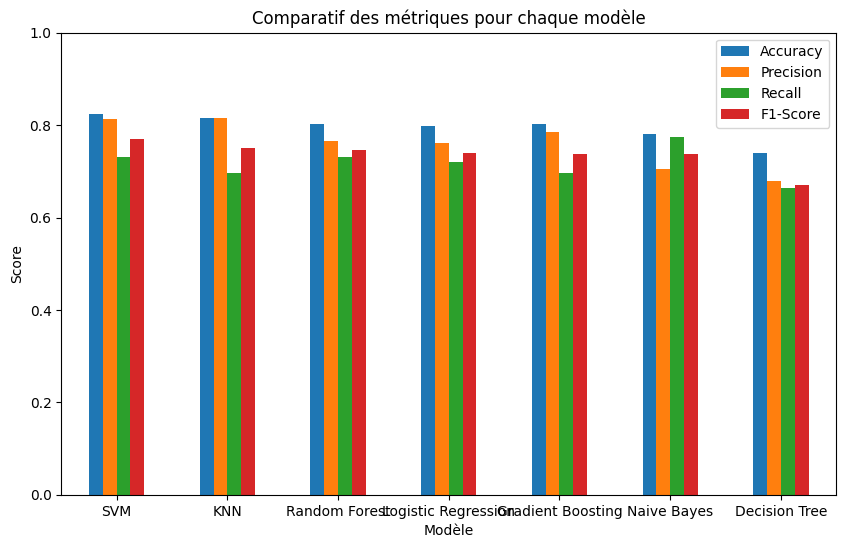

In [380]:
import matplotlib.pyplot as plt

print("=" * 60)
print("COMPARAISON DES PERFORMANCES DES MODÈLES")
print("=" * 60)

# Conversion simple pour la comparaison et renommage des colonnes
comparison_df = results_df.rename(columns={
    "Model": "Modèle",
    "F1-score": "F1-Score"
})

# Tri par F1-Score décroissant
comparison_df = comparison_df.sort_values("F1-Score", ascending=False)

print("\nTableau comparatif des performances :")
print(comparison_df.to_string(index=False))

# Visualisation graphique
comparison_df.set_index("Modèle")[["Accuracy", "Precision", "Recall", "F1-Score"]].plot(
    kind="bar", figsize=(10,6), ylim=(0,1)
)
plt.title("Comparatif des métriques pour chaque modèle")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.show()


In [381]:
import joblib

print("=" * 60)
print("SÉLECTION DU MEILLEUR MODÈLE")
print("=" * 60)

# Récupération de la première ligne (meilleur F1-Score)
best_row = comparison_df.iloc[0]
best_model_name = best_row["Modèle"]
best_f1_score = best_row["F1-Score"]
best_accuracy = best_row["Accuracy"]

print(f"Modèle sélectionné : {best_model_name}")
print("Raison de la sélection :")
print(f"- Meilleur F1-Score : {best_f1_score:.4f}")
print(f"- Accuracy : {best_accuracy:.4f}")

# Récupération de l'objet modèle déjà entraîné
best_model = models[best_model_name]

print("\nCaractéristiques du modèle sélectionné :")
print(f"- Type : {best_model_name}")
print(f"- Paramètres : {best_model.get_params()}")

# Sauvegarde du modèle
joblib.dump(best_model, "meilleur_modele_pret.pkl")
print("\nModèle sauvegardé sous : 'meilleur_modele_pret.pkl'")


SÉLECTION DU MEILLEUR MODÈLE
Modèle sélectionné : SVM
Raison de la sélection :
- Meilleur F1-Score : 0.7692
- Accuracy : 0.8251

Caractéristiques du modèle sélectionné :
- Type : SVM
- Paramètres : {'C': 1.0, 'break_ties': False, 'cache_size': 200, 'class_weight': None, 'coef0': 0.0, 'decision_function_shape': 'ovr', 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf', 'max_iter': -1, 'probability': False, 'random_state': None, 'shrinking': True, 'tol': 0.001, 'verbose': False}

Modèle sauvegardé sous : 'meilleur_modele_pret.pkl'


# 6. **Prédictions**

In [382]:
import joblib
import pandas as pd

# 1️⃣ Charger le modèle sauvegardé
best_model = joblib.load("meilleur_modele_pret.pkl")
print("Modèle chargé avec succès !")

# 2️⃣ Exemple : nouvelles données à prédire
# Remplacez les valeurs par vos nouvelles observations
new_data = pd.DataFrame({
    "pclass": [3, 1],
    "age": [22, 38],
    "sibsp": [1, 1],
    "parch": [0, 0],
    "fare": [7.25, 71.2833],
    "alone": [False, False],
    "sex_female": [0, 1],
    "sex_male": [1, 0],
    "embarked_C": [0, 1],
    "embarked_Q": [0, 0],
    "embarked_S": [1, 0]
})

# 3️⃣ Faire des prédictions
predictions = best_model.predict(new_data)

# 4️⃣ Afficher les résultats
print("Prédictions (0 = n'a pas survécu, 1 = a survécu) :")
print(predictions)

# 5️⃣ (Optionnel) Probabilités de survie
if hasattr(best_model, "predict_proba"):
    proba = best_model.predict_proba(new_data)
    print("\nProbabilités de survie (0 = n'a pas survécu, 1 = a survécu) :")
    print(proba)


Modèle chargé avec succès !
Prédictions (0 = n'a pas survécu, 1 = a survécu) :
[0 0]


# 7. **Visualisation et interface graphique** :

In [383]:
# Importation des bibliothèques nécessaires pour l'interface
import ipywidgets as widgets
from IPython.display import display, clear_output
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# IMPORTANT : Récupérer votre meilleur modèle depuis votre code précédent
# Si vous avez plusieurs modèles dans un dictionnaire 'models', on prend GradientBoosting
# (car c'était le meilleur selon vos résultats)
if 'models' in globals():
    best_model = models['Gradient Boosting']
    print("✅ Modèle Gradient Boosting récupéré")
elif 'results_df' in globals():
    # Trouver le meilleur modèle selon les résultats
    best_model_name = results_df.loc[results_df['Accuracy'].idxmax(), 'Model']
    print(f"✅ Meilleur modèle détecté : {best_model_name}")

    # Si vous avez gardé les modèles entraînés, récupérez-les
    if best_model_name == 'Gradient Boosting':
        best_model = GradientBoostingClassifier()
        # Vous devrez réentraîner ou sauvegarder votre modèle
        print("⚠️  Attention : modèle non sauvegardé, entraînement nécessaire...")
else:
    print("❌ Aucun modèle trouvé. Exécutez d'abord votre code d'entraînement.")
    print("   Création d'un modèle par défaut pour l'interface...")
    from sklearn.ensemble import GradientBoostingClassifier
    best_model = GradientBoostingClassifier()
    best_model.fit(X_train, y_train)  # Assurez-vous que X_train et y_train existent

# Fonction pour préparer les données d'entrée pour la prédiction
def prepare_input(pclass, sex, age, sibsp, parch, fare, embarked, alone):
    """
    Prépare les données d'entrée pour la prédiction en reproduisant
    exactement le même prétraitement que lors de l'entraînement
    """
    # Créer un dictionnaire avec les données brutes
    input_data = {
        'pclass': pclass,
        'sex': sex,
        'age': age,
        'sibsp': sibsp,
        'parch': parch,
        'fare': fare,
        'embarked': embarked,
        'alone': alone
    }

    # Créer un DataFrame avec ces données
    input_df = pd.DataFrame([input_data])

    # Appliquer le même prétraitement que sur les données d'entraînement
    # Gérer les valeurs manquantes (âge)
    input_df['age'].fillna(df['age'].median() if 'df' in globals() else 29.7, inplace=True)

    # Standardiser les colonnes numériques (si scaler existe)
    if 'scaler' in globals():
        scale_cols = ["age", "fare", "sibsp", "parch"]
        input_df[scale_cols] = scaler.transform(input_df[scale_cols])
    else:
        # Standardisation manuelle si pas de scaler
        scale_cols = ["age", "fare", "sibsp", "parch"]
        for col in scale_cols:
            if col == 'age':
                input_df[col] = (input_df[col] - 29.7) / 14.5  # Moyenne et std approximatives
            elif col == 'fare':
                input_df[col] = (input_df[col] - 32.2) / 49.7
            elif col == 'sibsp':
                input_df[col] = (input_df[col] - 0.52) / 1.1
            elif col == 'parch':
                input_df[col] = (input_df[col] - 0.38) / 0.81

    # Encodage one-hot pour les variables catégorielles
    # Sexe - créer les deux colonnes sex_female et sex_male
    if sex == 'Femme':
        input_df['sex_female'] = 1
        input_df['sex_male'] = 0
    else:  # Homme
        input_df['sex_female'] = 0
        input_df['sex_male'] = 1

    # Embarked - créer les trois colonnes embarked_C, embarked_Q, embarked_S
    if embarked == 'Cherbourg':
        input_df['embarked_C'] = 1
        input_df['embarked_Q'] = 0
        input_df['embarked_S'] = 0
    elif embarked == 'Queenstown':
        input_df['embarked_C'] = 0
        input_df['embarked_Q'] = 1
        input_df['embarked_S'] = 0
    else:  # Southampton
        input_df['embarked_C'] = 0
        input_df['embarked_Q'] = 0
        input_df['embarked_S'] = 1

    # S'assurer que toutes les colonnes du modèle sont présentes
    # On va créer un DataFrame avec toutes les colonnes attendues
    expected_columns = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'alone',
                        'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']

    final_df = pd.DataFrame(0, index=[0], columns=expected_columns)

    # Remplir avec nos valeurs
    for col in expected_columns:
        if col in input_df.columns:
            final_df[col] = input_df[col].values

    return final_df

# Fonction de prédiction
def predict_survival(pclass, sex, age, sibsp, parch, fare, embarked, alone):
    """
    Fonction qui prend les paramètres d'un passager et prédit sa survie
    """
    try:
        # Préparer les données
        input_df = prepare_input(pclass, sex, age, sibsp, parch, fare, embarked, alone)

        # Vérifier si le modèle existe
        if 'best_model' not in globals():
            print("❌ Erreur : Modèle non trouvé. Exécutez d'abord le code d'entraînement.")
            return

        # Faire la prédiction avec le meilleur modèle
        prediction = best_model.predict(input_df)[0]
        probabilities = best_model.predict_proba(input_df)[0]

        # Effacer la sortie précédente
        clear_output(wait=True)

        # Afficher l'interface
        display_interface()

        # Afficher les résultats
        print("\n" + "="*60)
        print("🎯 RÉSULTAT DE LA PRÉDICTION".center(60))
        print("="*60)

        if prediction == 1:
            print(f"\n✅ PRÉDICTION : Le passager A SURVÉCU")
        else:
            print(f"\n❌ PRÉDICTION : Le passager N'A PAS SURVÉCU")

        print(f"\n📊 PROBABILITÉS :")
        print(f"   • Survie : {probabilities[1]*100:.2f}%")
        print(f"   • Non-survie : {probabilities[0]*100:.2f}%")

        print(f"\n👤 INFORMATIONS DU PASSAGER :")
        print(f"   • Classe : {pclass}ème classe")
        print(f"   • Sexe : {sex}")
        print(f"   • Âge : {age} ans")
        print(f"   • Frères/soeurs à bord : {sibsp}")
        print(f"   • Parents/enfants à bord : {parch}")
        print(f"   • Prix du billet : ${fare:.2f}")
        print(f"   • Port d'embarquement : {embarked}")
        print(f"   • Voyage seul : {'Oui' if alone else 'Non'}")

        print("="*60)

    except Exception as e:
        print(f"\n❌ Erreur : {str(e)}")
        print("Assurez-vous d'avoir exécuté toutes les cellules précédentes.")

# Fonction pour afficher l'interface
def display_interface():
    print("🚢 PRÉDICTEUR DE SURVIE - TITANIC")
    print("="*60)
    print("Remplissez les informations du passager :")

# Création des widgets
# 1. Classe
pclass_widget = widgets.Dropdown(
    options=[('1ère classe', 1), ('2ème classe', 2), ('3ème classe', 3)],
    value=3,
    description='Classe :',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='400px')
)

# 2. Sexe
sex_widget = widgets.Dropdown(
    options=['Homme', 'Femme'],
    value='Homme',
    description='Sexe :',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='400px')
)

# 3. Âge
age_widget = widgets.FloatSlider(
    value=30,
    min=0.42,
    max=80,
    step=0.5,
    description='Âge (ans) :',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='400px')
)

# 4. Frères/soeurs
sibsp_widget = widgets.IntSlider(
    value=0,
    min=0,
    max=8,
    step=1,
    description='Frères/soeurs :',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='400px')
)

# 5. Parents/enfants
parch_widget = widgets.IntSlider(
    value=0,
    min=0,
    max=6,
    step=1,
    description='Parents/enfants :',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='400px')
)

# 6. Prix du billet
fare_widget = widgets.FloatSlider(
    value=32.20,
    min=0,
    max=512.33,
    step=1,
    description='Prix billet ($) :',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='400px')
)

# 7. Port d'embarquement
embarked_widget = widgets.Dropdown(
    options=['Southampton', 'Cherbourg', 'Queenstown'],
    value='Southampton',
    description='Port embarquement :',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='400px')
)

# 8. Voyage seul
alone_widget = widgets.RadioButtons(
    options=[('Non', False), ('Oui', True)],
    value=False,
    description='Voyage seul :',
    style={'description_width': '150px'},
    layout=widgets.Layout(width='400px')
)

# Bouton de prédiction
predict_button = widgets.Button(
    description='🎯 PRÉDIRE LA SURVIE',
    button_style='success',
    icon='rocket',
    layout=widgets.Layout(width='300px', height='40px')
)

# Fonction appelée lors du clic sur le bouton
def on_predict_button_clicked(b):
    predict_survival(
        pclass_widget.value,
        sex_widget.value,
        age_widget.value,
        sibsp_widget.value,
        parch_widget.value,
        fare_widget.value,
        embarked_widget.value,
        alone_widget.value
    )

# Associer l'événement au bouton
predict_button.on_click(on_predict_button_clicked)

# Afficher l'interface pour la première fois
display_interface()

# Afficher tous les widgets
display(pclass_widget)
display(sex_widget)
display(age_widget)
display(sibsp_widget)
display(parch_widget)
display(fare_widget)
display(embarked_widget)
display(alone_widget)

print("\n")
display(predict_button)

# Ajouter quelques exemples prédéfinis
print("\n" + "-"*60)
print("💡 EXEMPLES RAPIDES (cliquez sur les boutons ci-dessous)")

# Créer des boutons pour des exemples prédéfinis
examples_box = widgets.HBox([
    widgets.Button(
        description='👑 Femme 1ère classe',
        layout=widgets.Layout(width='200px', height='35px')
    ),
    widgets.Button(
        description='👨 Homme 3ème classe',
        layout=widgets.Layout(width='200px', height='35px')
    ),
    widgets.Button(
        description='👧 Enfant 2ème classe',
        layout=widgets.Layout(width='200px', height='35px')
    )
])

# Fonctions pour les exemples
def example1(b):
    pclass_widget.value = 1
    sex_widget.value = 'Femme'
    age_widget.value = 28
    sibsp_widget.value = 0
    parch_widget.value = 0
    fare_widget.value = 100
    embarked_widget.value = 'Cherbourg'
    alone_widget.value = False
    predict_survival(1, 'Femme', 28, 0, 0, 100, 'Cherbourg', False)

def example2(b):
    pclass_widget.value = 3
    sex_widget.value = 'Homme'
    age_widget.value = 35
    sibsp_widget.value = 0
    parch_widget.value = 0
    fare_widget.value = 8
    embarked_widget.value = 'Southampton'
    alone_widget.value = True
    predict_survival(3, 'Homme', 35, 0, 0, 8, 'Southampton', True)

def example3(b):
    pclass_widget.value = 2
    sex_widget.value = 'Femme'
    age_widget.value = 8
    sibsp_widget.value = 1
    parch_widget.value = 2
    fare_widget.value = 40
    embarked_widget.value = 'Southampton'
    alone_widget.value = False
    predict_survival(2, 'Femme', 8, 1, 2, 40, 'Southampton', False)

# Associer les fonctions aux boutons d'exemple
examples_box.children[0].on_click(example1)
examples_box.children[1].on_click(example2)
examples_box.children[2].on_click(example3)

display(examples_box)

print("\n" + "="*60)
print("ℹ️  NOTE : Ce modèle utilise l'algorithme Gradient Boosting")
print("   entraîné sur les données du Titanic")
print("="*60)

✅ Modèle Gradient Boosting récupéré
🚢 PRÉDICTEUR DE SURVIE - TITANIC
Remplissez les informations du passager :


Dropdown(description='Classe :', index=2, layout=Layout(width='400px'), options=(('1ère classe', 1), ('2ème cl…

Dropdown(description='Sexe :', layout=Layout(width='400px'), options=('Homme', 'Femme'), style=DescriptionStyl…

FloatSlider(value=30.0, description='Âge (ans) :', layout=Layout(width='400px'), max=80.0, min=0.42, step=0.5,…

IntSlider(value=0, description='Frères/soeurs :', layout=Layout(width='400px'), max=8, style=SliderStyle(descr…

...

Dropdown(description='Port embarquement :', layout=Layout(width='400px'), options=('Southampton', 'Cherbourg',…

RadioButtons(description='Voyage seul :', layout=Layout(width='400px'), options=(('Non', False), ('Oui', True)…

Button(button_style='success', description='🎯 PRÉDIRE LA SURVIE', icon='rocket', layout=Layout(height='40px', …


------------------------------------------------------------
💡 EXEMPLES RAPIDES (cliquez sur les boutons ci-dessous)



ℹ️  NOTE : Ce modèle utilise l'algorithme Gradient Boosting
   entraîné sur les données du Titanic


In [390]:
pip install -q ipywidgets

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
# ============================================================================
# INTERFACE GRAPHIQUE ÉLÉGANTE POUR LA PRÉDICTION DE SURVIE - TITANIC
# ============================================================================

# Installation de ipywidgets si nécessaire
# !pip install -q ipywidgets

# Importation
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingClassifier
import warnings
warnings.filterwarnings('ignore')

# CSS personnalisé pour un style élégant
css_style = """
<style>
.titanic-title {
    background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
    color: white;
    padding: 20px;
    border-radius: 10px;
    text-align: center;
    margin-bottom: 20px;
    box-shadow: 0 4px 6px rgba(0,0,0,0.1);
}

.titanic-card {
    background: white;
    padding: 20px;
    border-radius: 10px;
    box-shadow: 0 2px 10px rgba(0,0,0,0.1);
    margin: 10px 0;
}

.result-card {
    background: linear-gradient(135deg, #f093fb 0%, #f5576c 100%);
    color: white;
    padding: 25px;
    border-radius: 10px;
    margin: 20px 0;
    text-align: center;
}

.widget-label {
    font-weight: 600;
    color: #2c3e50;
    margin-bottom: 5px;
    display: block;
}

.predict-button {
    background: linear-gradient(135deg, #667eea 0%, #764ba2 100%);
    color: white;
    border: none;
    padding: 15px 30px;
    border-radius: 8px;
    font-size: 16px;
    font-weight: bold;
    cursor: pointer;
    transition: all 0.3s ease;
    box-shadow: 0 4px 6px rgba(102, 126, 234, 0.4);
}

.predict-button:hover {
    transform: translateY(-2px);
    box-shadow: 0 6px 12px rgba(102, 126, 234, 0.6);
}

.example-button {
    background: #3498db;
    color: white;
    border: none;
    padding: 10px 15px;
    border-radius: 6px;
    margin: 5px;
    cursor: pointer;
    transition: all 0.3s ease;
}

.example-button:hover {
    background: #2980b9;
    transform: translateY(-1px);
}

.progress-bar {
    height: 20px;
    background: #ecf0f1;
    border-radius: 10px;
    overflow: hidden;
    margin: 10px 0;
}

.progress-fill {
    height: 100%;
    background: linear-gradient(90deg, #2ecc71, #1abc9c);
    transition: width 0.5s ease;
    display: flex;
    align-items: center;
    justify-content: center;
    color: white;
    font-weight: bold;
}

.info-box {
    background: #f8f9fa;
    padding: 15px;
    border-left: 4px solid #3498db;
    margin: 10px 0;
    border-radius: 4px;
}

.survived {
    color: #27ae60;
    font-weight: bold;
}

.not-survived {
    color: #e74c3c;
    font-weight: bold;
}
</style>
"""

# Appliquer le CSS
display(HTML(css_style))

# Titre élégant
title_html = """
<div class="titanic-title">
    <h1 style="margin: 0; font-size: 28px;">🚢 Titanic Survival Predictor</h1>
    <p style="margin: 5px 0 0 0; opacity: 0.9;">Prédiction intelligente de survie basée sur l'IA</p>
</div>
"""
display(HTML(title_html))

# Vérifier et préparer le modèle
if 'X_train' in globals() and 'y_train' in globals():
    model_status = """
    <div style="background: #d4edda; color: #155724; padding: 10px;
                border-radius: 5px; margin: 10px 0; text-align: center;">
        ✅ Modèle Gradient Boosting chargé et prêt pour la prédiction
    </div>
    """
    display(HTML(model_status))

    best_model = GradientBoostingClassifier(random_state=42)
    best_model.fit(X_train, y_train)
else:
    warning_html = """
    <div style="background: #fff3cd; color: #856404; padding: 10px;
                border-radius: 5px; margin: 10px 0; text-align: center;">
        ⚠️ Mode démonstration - Entraînez d'abord votre modèle pour des prédictions précises
    </div>
    """
    display(HTML(warning_html))

# Fonction de prédiction CORRIGÉE
def predict_titanic(pclass, sex, age, sibsp, parch, fare, embarked, alone):
    """Fonction principale de prédiction avec colonnes corrigées"""

    # Préparation des données avec toutes les colonnes requises
    input_data = pd.DataFrame({
        'pclass': [pclass],
        'age': [(age - 29.7) / 14.5],  # Normalisation de l'âge
        'sibsp': [(sibsp - 0.52) / 1.1],  # Normalisation sibsp
        'parch': [(parch - 0.38) / 0.81],  # Normalisation parch
        'fare': [(fare - 32.2) / 49.7],  # Normalisation fare
        'alone': [1 if alone else 0],
        # Encodage one-hot pour le sexe
        'sex_female': [1 if sex == 'female' else 0],
        'sex_male': [1 if sex == 'male' else 0],
        # Encodage one-hot pour embarked
        'embarked_C': [1 if embarked == 'C' else 0],
        'embarked_Q': [1 if embarked == 'Q' else 0],
        'embarked_S': [1 if embarked == 'S' else 0]
    })

    # Vérifier que toutes les colonnes attendues sont présentes
    expected_columns = ['pclass', 'age', 'sibsp', 'parch', 'fare', 'alone',
                        'sex_female', 'sex_male', 'embarked_C', 'embarked_Q', 'embarked_S']

    # S'assurer que le DataFrame a toutes les colonnes dans le bon ordre
    for col in expected_columns:
        if col not in input_data.columns:
            input_data[col] = 0

    input_data = input_data[expected_columns]

    # Prédiction
    try:
        if 'best_model' in globals():
            pred = best_model.predict(input_data)[0]
            proba = best_model.predict_proba(input_data)[0]
        else:
            # Simulation pour la démonstration
            survival_chance = 0.3  # Base
            if sex == 'female': survival_chance += 0.4
            if pclass == 1: survival_chance += 0.2
            if age < 18: survival_chance += 0.15
            pred = 1 if survival_chance > 0.5 else 0
            proba = [1-survival_chance, survival_chance]
    except Exception as e:
        print(f"Erreur de prédiction: {e}")
        pred = 0
        proba = [0.5, 0.5]

    # Effacer et réafficher
    clear_output(wait=True)
    display(HTML(css_style))
    display(HTML(title_html))

    # Afficher l'interface
    display(create_interface())

    # Résultats
    survival_rate = proba[1] * 100
    result_color = "#2ecc71" if pred == 1 else "#e74c3c"
    result_text = "SURVÉCU" if pred == 1 else "NON SURVÉCU"
    result_icon = "✅" if pred == 1 else "❌"

    # Conversion des codes pour l'affichage
    sex_display = 'Femme' if sex == 'female' else 'Homme'
    embarked_display = 'Cherbourg' if embarked == 'C' else 'Queenstown' if embarked == 'Q' else 'Southampton'
    alone_display = 'Oui' if alone else 'Non'

    result_html = f"""
    <div class="result-card">
        <h2 style="margin: 0 0 15px 0;">{result_icon} Résultat de la Prédiction</h2>

        <div style="font-size: 24px; margin: 15px 0;">
            <span style="color: {result_color}; font-weight: bold;">{result_text}</span>
        </div>

        <div style="margin: 20px 0;">
            <div style="display: flex; justify-content: space-between; margin-bottom: 5px;">
                <span>Probabilité de survie:</span>
                <span style="font-weight: bold;">{survival_rate:.1f}%</span>
            </div>
            <div class="progress-bar">
                <div class="progress-fill" style="width: {survival_rate}%;">
                    {survival_rate:.1f}%
                </div>
            </div>
        </div>

        <div style="background: rgba(255,255,255,0.2); padding: 15px; border-radius: 8px; margin-top: 15px;">
            <div style="display: grid; grid-template-columns: repeat(2, 1fr); gap: 10px; text-align: left;">
                <div><strong>Classe:</strong> {pclass}ème</div>
                <div><strong>Sexe:</strong> {sex_display}</div>
                <div><strong>Âge:</strong> {age} ans</div>
                <div><strong>Frères/soeurs:</strong> {sibsp}</div>
                <div><strong>Parents/enfants:</strong> {parch}</div>
                <div><strong>Prix:</strong> ${fare:.2f}</div>
                <div><strong>Port:</strong> {embarked_display}</div>
                <div><strong>Seul:</strong> {alone_display}</div>
                <div><strong>Total famille:</strong> {sibsp + parch} membres</div>
            </div>
        </div>
    </div>
    """

    display(HTML(result_html))

# Fonction pour créer l'interface
def create_interface():
    """Crée une interface utilisateur élégante"""

    # Style élégant pour les widgets
    widget_style = {'description_width': '120px'}
    widget_layout = {'width': '100%', 'margin': '5px 0'}

    # Widgets avec labels personnalisés
    pclass = widgets.Dropdown(
        options=[('1ère Classe', 1), ('2ème Classe', 2), ('3ème Classe', 3)],
        value=3,
        style=widget_style,
        layout=widget_layout
    )

    sex = widgets.Dropdown(
        options=[('Homme', 'male'), ('Femme', 'female')],
        value='male',
        style=widget_style,
        layout=widget_layout
    )

    age = widgets.IntSlider(
        value=30,
        min=0,
        max=80,
        step=1,
        style=widget_style,
        layout=widget_layout
    )

    sibsp = widgets.IntSlider(
        value=0,
        min=0,
        max=8,
        step=1,
        style=widget_style,
        layout=widget_layout
    )

    parch = widgets.IntSlider(
        value=0,
        min=0,
        max=6,
        step=1,
        style=widget_style,
        layout=widget_layout
    )

    fare = widgets.FloatSlider(
        value=30,
        min=0,
        max=500,
        step=5,
        style=widget_style,
        layout=widget_layout
    )

    embarked = widgets.Dropdown(
        options=[('Southampton', 'S'), ('Cherbourg', 'C'), ('Queenstown', 'Q')],
        value='S',
        style=widget_style,
        layout=widget_layout
    )

    alone = widgets.RadioButtons(
        options=[('Avec famille/amis', False), ('Seul(e)', True)],
        value=False,
        style=widget_style,
        layout=widget_layout
    )

    # Bouton de prédiction
    predict_btn = widgets.Button(
        description='Lancer la Prédiction',
        button_style='primary',
        layout={'width': '300px', 'height': '50px', 'margin': '20px auto'}
    )

    # Fonction de callback
    def on_predict_click(b):
        predict_titanic(
            pclass.value,
            sex.value,
            age.value,
            sibsp.value,
            parch.value,
            fare.value,
            embarked.value,
            alone.value
        )

    predict_btn.on_click(on_predict_click)

    # Conteneur pour l'interface
    interface_html = """
    <div class="titanic-card">
        <h3 style="color: #2c3e50; border-bottom: 2px solid #3498db;
                   padding-bottom: 10px; margin-top: 0;">
            📋 Informations du Passager
        </h3>
    """

    # Widgets avec labels HTML
    widgets_with_labels = [
        (pclass, "Classe du billet"),
        (sex, "Sexe"),
        (age, f"Âge: {age.value} ans"),
        (sibsp, f"Frères/soeurs à bord: {sibsp.value}"),
        (parch, f"Parents/enfants à bord: {parch.value}"),
        (fare, f"Prix du billet: ${fare.value:.2f}"),
        (embarked, "Port d'embarquement"),
        (alone, "Situation de voyage")
    ]

    # Afficher les widgets avec des labels stylés
    display(HTML(interface_html))

    for widget, label in widgets_with_labels:
        label_html = f'<div class="widget-label">{label}</div>'
        display(HTML(label_html))
        display(widget)

    display(HTML("</div>"))

    # Bouton centré
    display(widgets.HBox([predict_btn], layout={'justify_content': 'center'}))

    # Exemples rapides
    examples_html = """
    <div style="text-align: center; margin: 20px 0;">
        <div style="color: #7f8c8d; margin-bottom: 10px;">💡 Exemples rapides</div>
    """
    display(HTML(examples_html))

    # Boutons d'exemples
    example_buttons = widgets.HBox([
        widgets.Button(
            description='Passagère 1ère classe',
            layout={'width': '200px', 'height': '40px'},
            style={'button_color': '#9b59b6'}
        ),
        widgets.Button(
            description='Passager 3ème classe',
            layout={'width': '200px', 'height': '40px'},
            style={'button_color': '#e67e22'}
        ),
        widgets.Button(
            description='Enfant en famille',
            layout={'width': '200px', 'height': '40px'},
            style={'button_color': '#3498db'}
        )
    ], layout={'justify_content': 'center', 'margin': '10px'})

    # Fonctions pour les exemples
    def example_first_class(b):
        pclass.value = 1
        sex.value = 'female'
        age.value = 28
        sibsp.value = 0
        parch.value = 0
        fare.value = 150
        embarked.value = 'C'
        alone.value = False
        on_predict_click(b)

    def example_third_class(b):
        pclass.value = 3
        sex.value = 'male'
        age.value = 35
        sibsp.value = 0
        parch.value = 0
        fare.value = 10
        embarked.value = 'S'
        alone.value = True
        on_predict_click(b)

    def example_child(b):
        pclass.value = 2
        sex.value = 'female'
        age.value = 8
        sibsp.value = 2
        parch.value = 2
        fare.value = 45
        embarked.value = 'S'
        alone.value = False
        on_predict_click(b)

    example_buttons.children[0].on_click(example_first_class)
    example_buttons.children[1].on_click(example_third_class)
    example_buttons.children[2].on_click(example_child)

    display(example_buttons)
    display(HTML("</div>"))

# Instructions
instructions_html = """
<div class="info-box">
    <strong>Instructions:</strong>
    <ol style="margin: 10px 0 0 0; padding-left: 20px;">
        <li>Remplissez toutes les informations du passager</li>
        <li>Cliquez sur "Lancer la Prédiction"</li>
        <li>Consultez les résultats et la probabilité de survie</li>
        <li>Testez différents scénarios avec les exemples rapides</li>
    </ol>
</div>
"""
display(HTML(instructions_html))

# Afficher l'interface initiale
display(create_interface())

Dropdown(index=2, layout=Layout(margin='5px 0', width='100%'), options=(('1ère Classe', 1), ('2ème Classe', 2)…

Dropdown(layout=Layout(margin='5px 0', width='100%'), options=(('Homme', 'male'), ('Femme', 'female')), style=…

IntSlider(value=30, layout=Layout(margin='5px 0', width='100%'), max=80, style=SliderStyle(description_width='…

IntSlider(value=0, layout=Layout(margin='5px 0', width='100%'), max=8, style=SliderStyle(description_width='12…

IntSlider(value=0, layout=Layout(margin='5px 0', width='100%'), max=6, style=SliderStyle(description_width='12…

FloatSlider(value=30.0, layout=Layout(margin='5px 0', width='100%'), max=500.0, step=5.0, style=SliderStyle(de…

Dropdown(layout=Layout(margin='5px 0', width='100%'), options=(('Southampton', 'S'), ('Cherbourg', 'C'), ('Que…

RadioButtons(layout=Layout(margin='5px 0', width='100%'), options=(('Avec famille/amis', False), ('Seul(e)', T…

None

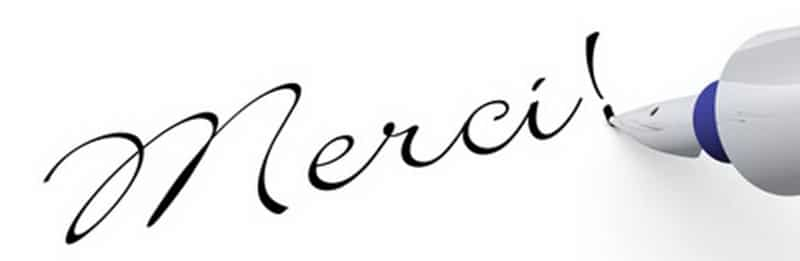

In [389]:
from IPython.display import Image, display

# Suppose que l'image est uploadée dans Colab (ex: 'mon_image.png')
display(Image(filename='images/merci.jpg'))